In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)


h:\DE\who-tb-analysis


In [3]:
from src.extract import get_dataset
from src.extract import save_raw_data

tb_raw = get_dataset("TB_rr_mdr")

tb_raw.head()

,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,Dim1,TimeDim,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
0,4860635,TB_rr_mdr,GLOBAL,GLOBAL,None,YEAR,None,None,None,2016,...,None,155 677,155677.0,None,None,None,2025-11-11T17:24:56.267+01:00,2016,2016-01-01T00:00:00+01:00,2016-12-31T00:00:00+01:00
1,9783849,TB_rr_mdr,WORLDBANKINCOMEGROUP,WB_LI,None,YEAR,None,None,None,2008,...,None,645,645.0,None,None,None,2025-11-11T17:24:56.267+01:00,2008,2008-01-01T00:00:00+01:00,2008-12-31T00:00:00+01:00
2,6607421,TB_rr_mdr,COUNTRY,ROU,EUR,YEAR,Europe,None,None,2022,...,None,270,270.0,None,None,None,2025-11-11T17:24:56.267+01:00,2022,2022-01-01T00:00:00+01:00,2022-12-31T00:00:00+01:00
3,2058547,TB_rr_mdr,COUNTRY,TJK,EUR,YEAR,Europe,None,None,2020,...,None,557,557.0,None,None,None,2025-11-11T17:24:56.267+01:00,2020,2020-01-01T00:00:00+01:00,2020-12-31T00:00:00+01:00
4,637009,TB_rr_mdr,COUNTRY,ZMB,AFR,YEAR,Africa,None,None,2020,...,None,484,484.0,None,None,None,2025-11-11T17:24:56.267+01:00,2020,2020-01-01T00:00:00+01:00,2020-12-31T00:00:00+01:00


In [ ]:
import os
print(os.getcwd())

In [4]:
save_raw_data(tb_raw,"tb_rr_mdr_raw.csv")

Saved: H:/DE/who-tb-analysis/data/raw/tb_rr_mdr_raw.csv


In [5]:
from src.transform import create_tb_dataset

In [6]:
tb = create_tb_dataset(tb_raw)

tb.head()



,country_code,region,year,rr_mdr_tb_cases
0,GLOBAL,None,2016,155677.0
1,WB_LI,None,2008,645.0
2,ROU,Europe,2022,270.0
3,TJK,Europe,2020,557.0
4,ZMB,Africa,2020,484.0


In [7]:
from src.transform import create_region_lookup

region_raw = get_dataset("RegionCountry")

region_lookup = create_region_lookup(region_raw)

region_lookup.head()

,CountryCode,CountryName,RegionCode,RegionName
0,ABW,Aruba,AMR,Americas
1,AFG,Afghanistan,EMR,Eastern Mediterranean
2,AGO,Angola,AFR,Africa
3,AIA,Anguilla,AMR,Americas
4,ALB,Albania,EUR,Europe


In [8]:
from src.transform import create_country_dataset

country_tb = create_country_dataset(
    tb_raw,
    region_raw
)

country_tb.head()

,country_code,region,year,rr_mdr_tb_cases,CountryCode,CountryName,RegionCode,RegionName
2,ROU,Europe,2022,270.0,ROU,Romania,EUR,Europe
3,TJK,Europe,2020,557.0,TJK,Tajikistan,EUR,Europe
4,ZMB,Africa,2020,484.0,ZMB,Zambia,AFR,Africa
5,THA,South-East Asia,2011,612.0,THA,Thailand,SEAR,South-East Asia
6,NOR,Europe,2015,6.0,NOR,Norway,EUR,Europe


In [9]:
print(country_tb.shape)

(3417, 8)


In [10]:
from src.transform import join_country_names, keep_countries_only
tb = create_tb_dataset(tb_raw)

region_lookup = create_region_lookup(region_raw)

joined_tb = join_country_names(
    tb,
    region_lookup
)

print("After join:", joined_tb.shape)

clean_tb = keep_countries_only(joined_tb)

print("Countries only:", clean_tb.shape)

After join: (3676, 8)
Countries only: (3417, 8)


In [11]:
from src.analysis import top_countries

top_countries(country_tb)

CountryName
India                 598682.0
Russian Federation    332997.0
South Africa          248046.0
China                 161161.0
Ukraine                98930.0
Kazakhstan             98535.0
Indonesia              86978.0
Philippines            86732.0
Pakistan               46366.0
Viet Nam               38157.0
Name: rr_mdr_tb_cases, dtype: float64

In [12]:
from src.analysis import yearly_trend

yearly_trend(country_tb)

year
2005     12095.0
2006     19491.0
2007     29994.0
2008     31171.0
2009     52790.0
2010     67000.0
2011     68689.0
2012    106522.0
2013    122315.0
2014    121614.0
2015    132451.0
2016    155633.0
2017    160233.0
2018    186829.0
2019    201974.0
2020    156912.0
2021    167238.0
2022    180335.0
2023    189590.0
2024    173276.0
Name: rr_mdr_tb_cases, dtype: float64

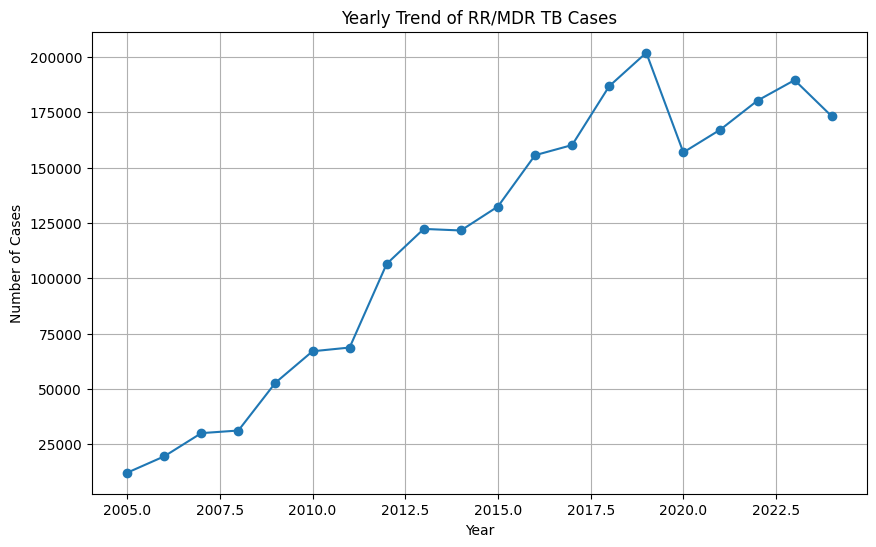

In [13]:
from src.analysis import plot_yearly_trend
plot_yearly_trend(country_tb)

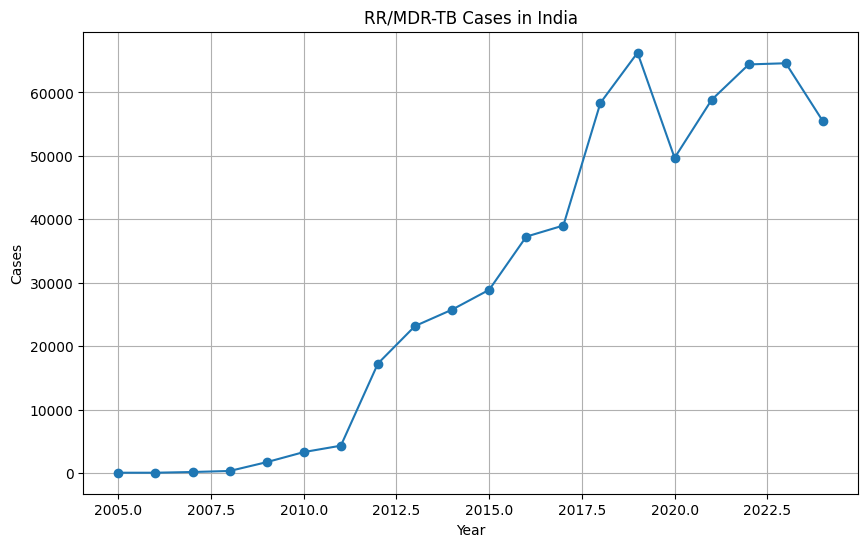

In [14]:
from src.analysis import country_trend, plot_country_trend
country_trend(country_tb, "India")
plot_country_trend(country_tb, "India")


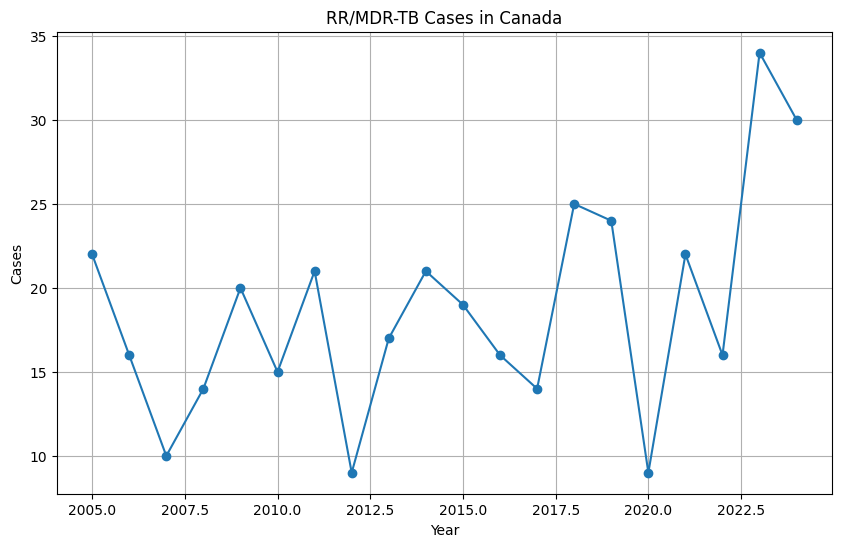

In [15]:
country_trend(country_tb, "Canada")
plot_country_trend(country_tb, "Canada")

In [16]:
from src.analysis import top_countries_by_year
top_countries_by_year(country_tb, 2024)

CountryName
India                 55447.0
Russian Federation    22807.0
China                 15255.0
Indonesia             11189.0
Philippines            7549.0
South Africa           6341.0
Pakistan               4609.0
Nigeria                3662.0
Viet Nam               3658.0
Ukraine                3645.0
Name: rr_mdr_tb_cases, dtype: float64